In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [98]:
#Load the Titanic dataset into a Pandas DataFrame.
df=pd.read_csv('titanic (4).csv')

In [99]:
#the first 5 rows of the dataset to get an overview
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [100]:
#Provide basic information about the dataset using the info() method
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [28]:
#4 Identify and count the number of missing values in each column.
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [29]:
df.isnull().sum()/len(df)*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [30]:
#5 dropping cabin column as it has more than 50% value as NULL
df.drop(columns='Cabin',inplace=True)

In [22]:
#Decide on an appropriate strategy for handling missing values in at least two columns and implement it.
df.fillna(df['Age'].mean(),inplace=True)

In [34]:
df.fillna({'Age':df['Age'].mean},inplace=True)

In [35]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

In [37]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [38]:
df['Embarked'].value_counts()/len(df)*100

Embarked
S    72.278339
C    18.855219
Q     8.641975
Name: count, dtype: float64

In [47]:
df[df['Embarked'].isnull()==True]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,NaN


In [55]:
df.dropna(subset='Embarked',inplace=True)

In [56]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [58]:
#6 Generate descriptive statistics for the numerical columns using the describe() method.
s1=df.corr(numeric_only=True)

In [60]:
s1.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,6.0,0.152167,0.416134,-0.057686,-0.027754,-0.003342,0.009113,1.0
Survived,6.0,0.160637,0.454101,-0.335549,-0.026787,0.039061,0.212256,1.0
Pclass,6.0,0.029901,0.532155,-0.548193,-0.260494,-0.009253,0.065448,1.0
SibSp,6.0,0.260893,0.400123,-0.057686,-0.005116,0.121271,0.351128,1.0
Parch,6.0,0.288399,0.381398,-0.001657,0.033406,0.150341,0.365289,1.0
Fare,6.0,0.183037,0.497602,-0.548193,0.049749,0.189209,0.245851,1.0


In [62]:
#7 • List unique values in the 'Pclass' column.
df['Pclass'].unique()

array([3, 1, 2], dtype=int64)

In [63]:
df['Embarked']

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 889, dtype: object

In [64]:
#8 Count the occurrences of each unique value in the 'Embarked' column
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [76]:
df['Embarked'].value_counts()/len(df)*100

Embarked
S    72.440945
C    18.897638
Q     8.661417
Name: count, dtype: float64

In [74]:
#9 Create a new column named 'FamilySize' that represents the sum of 'SibSp' and 'Parch'.

df['FamilySize']=df['SibSp']+df['Parch']

In [77]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


In [81]:
#10 Create a new DataFrame containing only passengers with an age greater than 30.
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


In [86]:
df['Sex'].value_counts()

Sex
male      577
female    312
Name: count, dtype: int64

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [103]:
df[df['Age']>30]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S
...,...,...,...,...,...,...,...,...,...,...,...,...
873,874,0,3,"Vander Cruyssen, Mr. Victor",male,47.0,0,0,345765,9.0000,NaN,S
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C
881,882,0,3,"Markun, Mr. Johann",male,33.0,0,0,349257,7.8958,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q


In [110]:
#11 Sort the DataFrame by 'Fare' in descending order.
df.sort_values('Fare',ascending=False)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
...,...,...,...,...,...,...,...,...,...,...,...,...
633,634,0,1,"Parr, Mr. William Henry Marsh",male,NaN,0,0,112052,0.0000,NaN,S
413,414,0,2,"Cunningham, Mr. Alfred Fleming",male,NaN,0,0,239853,0.0000,NaN,S
822,823,0,1,"Reuchlin, Jonkheer. John George",male,38.0,0,0,19972,0.0000,NaN,S
732,733,0,2,"Knight, Mr. Robert J",male,NaN,0,0,239855,0.0000,NaN,S


In [111]:
#12 Calculate the survival rate for different passenger classes ('Pclass’). Present it using Chart

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [121]:
s1=df.groupby('Pclass')['Survived'].sum()

In [122]:
s1

Pclass
1    136
2     87
3    119
Name: Survived, dtype: int64

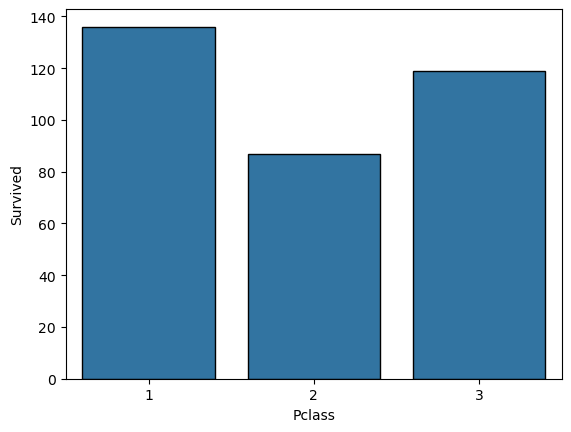

In [126]:
sns.barplot(df.groupby('Pclass')['Survived'].sum(),edgecolor='Black')
plt.show()

In [135]:
df.groupby('Pclass')['Survived'].sum()

Pclass
1    136
2     87
3    119
Name: Survived, dtype: int64

In [136]:
df.groupby('Pclass')['Survived'].sum()/df.groupby('Pclass')['Survived'].count()*100

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

In [153]:
#13 Identify and display the passenger with the highest 'Fare’.
df[df['Fare']==df['Fare'].max()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C


In [ ]:
#14 Create a bar plot using seaborn to visualize the count of survivors and non-survivors.

In [160]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,Survived,Not Survived,3,"Braund, Mr. Owen Harris",male,22.0,Survived,Not Survived,A/5 21171,7.25,NaN,S
1,2,Survived,Survived,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,Survived,Not Survived,PC 17599,71.2833,C85,C
2,3,Survived,3,"Heikkinen, Miss. Laina",female,26.0,Not Survived,Not Survived,STON/O2. 3101282,7.925,NaN,S
3,4,Survived,Survived,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,Survived,Not Survived,113803,53.1,C123,S
4,5,Not Survived,3,"Allen, Mr. William Henry",male,35.0,Not Survived,Not Survived,373450,8.05,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,Not Survived,2,"Montvila, Rev. Juozas",male,27.0,Not Survived,Not Survived,211536,13.0,NaN,S
887,888,Survived,Survived,"Graham, Miss. Margaret Edith",female,19.0,Not Survived,Not Survived,112053,30.0,B42,S
888,889,Not Survived,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,Survived,2,W./C. 6607,23.45,NaN,S
889,890,Survived,Survived,"Behr, Mr. Karl Howell",male,26.0,Not Survived,Not Survived,111369,30.0,C148,C


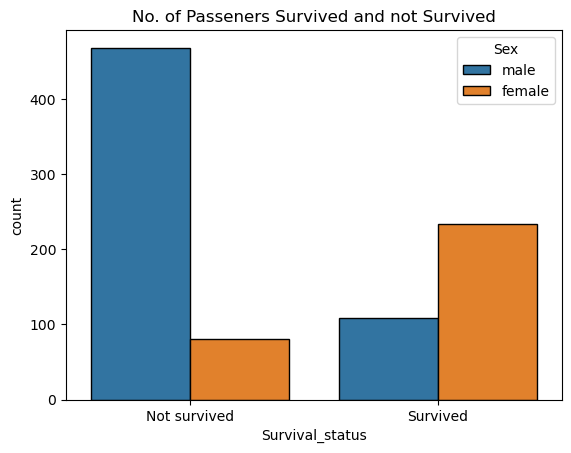

In [167]:
sns.countplot(data=df,x='Survival_status',edgecolor='Black',hue='Sex')
plt.title('No. of Passeners Survived and not Survived')
plt.show()

In [163]:
df['Survival_status']=df['Survived'].map({0:'Not survived',1:'Survived'})

In [168]:
#15 Create a histogram using matplotlib to show the distribution of passenger ages.
df['Age'].max()

80.0

In [169]:
df['Age'].min()

0.42

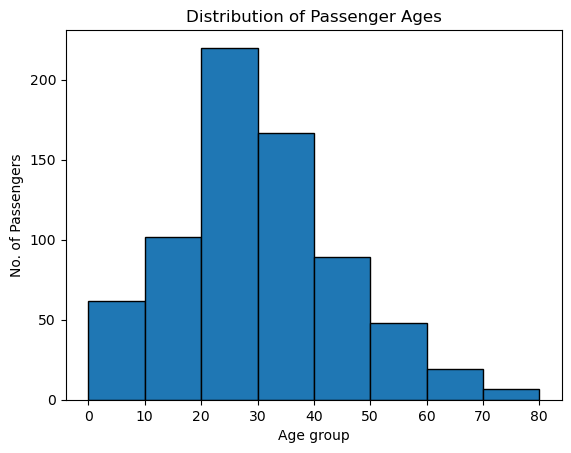

In [178]:
plt.hist(x=df['Age'],bins=[0,10,20,30,40,50,60,70,80],edgecolor='black')
plt.xticks([0,10,20,30,40,50,60,70,80])
plt.title('Distribution of Passenger Ages')
plt.xlabel('Age group')
plt.ylabel('No. of Passengers')
plt.show()

In [180]:
s1=df['Pclass'].value_counts()

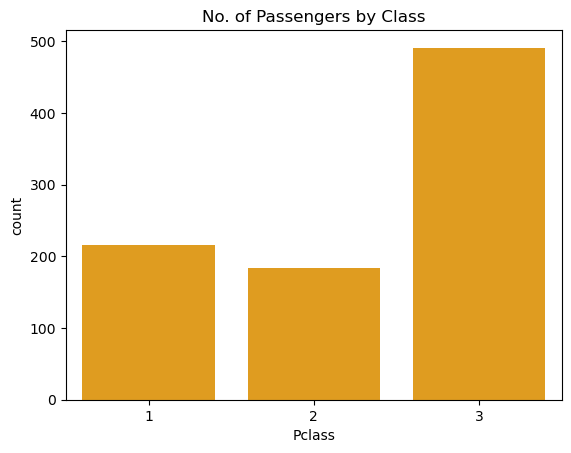

In [193]:
#16 Use seaborn to create a count plot to display the number of passengers in each class.
sns.countplot(data=df,x='Pclass',color=
              'Orange')
plt.title('No. of Passengers by Class')
plt.show()

In [ ]:
#17 Create a box plot using seaborn to visualize the distribution of passenger fares.

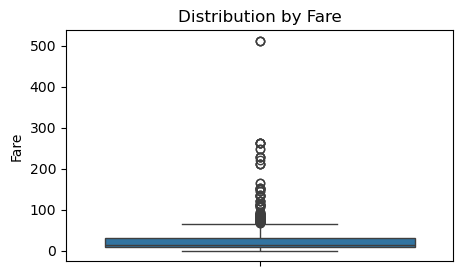

In [196]:
plt.figure(figsize=(5,3))
sns.boxplot(data=df,y='Fare')
plt.title('Distribution by Fare')
plt.show()

In [198]:
#18 Generate a heatmap using seaborn to visualize the correlation matrix of the numerical variables in the dataset.
df_numeric=df.corr(numeric_only=True)

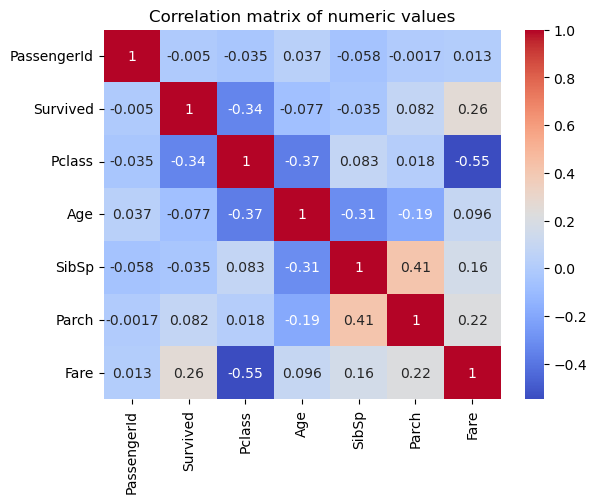

In [204]:
sns.heatmap(data=df_numeric,cmap='coolwarm',annot=True)
plt.title('Correlation matrix of numeric values')
plt.show()

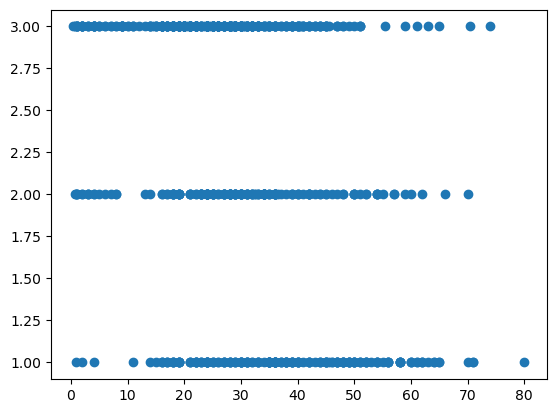

<Figure size 500x300 with 0 Axes>

In [206]:
#19 Create a scatter plot using matplotlib to show the relationship between passenger age and class
plt.scatter(x=df['Age'],y=df['Pclass'])
plt.figure(figsize=(5,3))
plt.show()

In [207]:
#20 Write conclusion about your findings from data analysis

In [ ]:
1. No. of people Survived more in class 1 than others.
2. Female Survival rate is higher than Males.
3. people are travelling more of a Age group of 20-30.
4. People are travelling more in class 3.
5. People of higher age is travelling in class 1.